In [1]:
pwd

'/Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper/version2/scripts_data_for_beh_paper/code/4_across_tasks_behavioronly'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
path_to_add = os.path.abspath('../')
print('path_to_add:',path_to_add)
sys.path.append(path_to_add)
from func_fix_curvefit_params import *
import numpy as np

path_to_add: /Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper/version2/scripts_data_for_beh_paper/code


In [3]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

# Load curvefit terms


In [4]:
def get_p(p):
    if p < .001:
        return "p<.001"
    elif p < .01:
        return f"p={p:.3f}"
    else:
        return f"p={p:.2f}"

In [5]:
both_expts_merged = pd.read_csv('../../data/subtlety_playfight_data/curvefit_traits_merged_linearpf_onlyneccols_fight.csv', index_col='subID')
both_expts_merged.drop(columns='Unnamed: 0',inplace=True)
both_expts_merged.head()

,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,0.552951,0.900821,0.315504,0.103360,0.513054,0.784286,0.784286,0.452539,21.0,23.0,...,16.000000,20.0,0.0,38.0,28.000000,31.000000,34.0,39.0,56.0,3.0
30004.0,0.276896,0.805834,0.999458,0.076866,0.872907,0.469286,0.469286,0.170256,21.0,20.0,...,15.000000,25.0,11.0,38.0,26.181818,50.000000,50.0,46.0,56.0,3.0
30005.0,0.320583,0.710131,0.861730,0.115353,0.501696,0.842143,0.842143,0.490950,17.0,29.0,...,16.000000,20.0,21.0,51.0,39.000000,40.000000,43.0,19.0,41.0,5.0
30006.0,0.464823,0.989396,0.889572,0.079221,0.741046,0.674587,0.674587,0.000307,8.0,10.0,...,3.000000,25.0,0.0,18.0,41.000000,31.000000,44.0,57.0,30.0,4.0
30008.0,0.325118,0.582252,0.692710,0.172585,0.677591,0.511071,0.511071,0.314366,5.0,15.0,...,12.222222,28.0,4.0,27.0,46.000000,42.545455,46.0,50.0,45.0,5.0


In [6]:
both_expts_merged.columns

Index(['PSE_subt', 'range_subt', 'bias_subt', 'sigma_subt', 'PSE_pf',
       'slope_pf', 'range_pf', 'bias_pf', 'social_skill', 'attn_switch', 'img',
       'attn_to_det', 'comm', 'posAffect', 'negAffect', 'neuroticism',
       'extraversion', 'openness', 'agreeableness', 'conscientiousness',
       'loneliness', 'nfriends'],
      dtype='object')

In [7]:
cmap = 'BrBG'#'RdBu_r'

In [8]:
results_loc = '../../results/subtlety_playfight_mixed/across_task_beh_composite/'

In [9]:
def plot_corr(xcol,ycol,ax,asp=True):

    x = both_expts_merged[xcol]
    y = both_expts_merged[ycol]

    sns.regplot(x=x, y=y,ax=ax,color = 'grey',scatter_kws={'s': 10, 'marker': '.'})

    rows = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
    
    x = x[rows]
    y = y[rows]

    r_p,p_p = stats.pearsonr(x,y)
    r_s,p_s = stats.spearmanr(x,y)

    if (p_p < .05):
        fontweight = 'bold'
        color = 'k'
    else:
        fontweight = 'normal'
        color = 'k'
    ax.annotate(f'r={r_p:.2f}\n({get_p(p_p)})', xy = (.05,1),xycoords='axes fraction',fontweight = fontweight, color = color,fontsize=14, va = 'top')

    if (p_s < .05):
        fontweight = 'bold'
        color = 'k'
    else:
        fontweight = 'normal'
        color = 'k'
    if asp == True:
        ax.set_aspect('equal')
    else:
        ax.set_aspect('auto')
    
    limits = [-0.05,1.05]
    ax.set_xlim(limits)
    ax.set_ylim(limits)

    ticks =[0,0.5,1]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='x', colors='tab:blue')  # x-axis tick labels color set to red
    ax.tick_params(axis='y', colors='tab:red')  # y-axis tick labels color set to red

    ax.set_xlabel('_'.join(xcol.split('_')[:-1]), color = 'tab:blue')
    ax.set_ylabel('_'.join(ycol.split('_')[:-1]), color = 'tab:red')
    
    ax.spines['bottom'].set_color('tab:blue')  # X-axis color
    ax.spines['left'].set_color('tab:red')     # Y-axis color

    return r_p, x.shape[0]

In [10]:
cols_req_subt = ['subID','PSE','range','bias']
cols_req_pf = ['subID','range','bias']

In [11]:
cols_req_subt = [i + '_subt' if i != 'subID' else i for i in cols_req_subt]
cols_req_pf = [i + '_pf' if i != 'subID' else i for i in cols_req_pf]
cols_req_all = cols_req_subt + cols_req_pf[1:]
cols_req_all

['subID', 'PSE_subt', 'range_subt', 'bias_subt', 'range_pf', 'bias_pf']

In [12]:
subt_cols = [i + '_subt' for i in cols_req_subt[1:]]
pf_cols = [i + '_pf' for i in cols_req_pf[1:]]

r_all = np.full((len(cols_req_all[1:]),len(cols_req_all[1:])),np.nan)
p_all = np.full((len(cols_req_all[1:]),len(cols_req_all[1:])),np.nan)
for i,row1 in enumerate(cols_req_all[1:]):
    for j,row2 in enumerate(cols_req_all[1:]):
        if j <= i:
            x = both_expts_merged[row1]
            y = both_expts_merged[row2]
            rows = ~(np.isnan(x)) & ~(np.isnan(y)) & ~(np.isinf(x)) & ~(np.isinf(y))
            x = x[rows]
            y = y[rows]
            r_all[i,j], p_all[i,j] = stats.pearsonr(x,y)
        else:
            r_all[i,j], p_all[i,j] = np.nan,np.nan

from multipy.fdr import lsu

refx = np.array([[0, 0, 0, 0, 0],[1,1,1,1,1],[2,2,2,2,2],[3,3,3,3,3],[4,4,4,4,4]])
refy = np.array([[0, 0, 0, 0, 0],[1,1,1,1,1],[2,2,2,2,2],[3,3,3,3,3],[4,4,4,4,4]]).T

refx = refx[~np.isnan(r_all) & (r_all<0.9999)]
refy = refy[~np.isnan(r_all) & (r_all<0.9999)]

p_all_reqcorr = p_all[~np.isnan(r_all) & (r_all<0.9999)]
# Flatten the 2D array to 1D
p_all_flattened = p_all_reqcorr.flatten()
refx_flat = refx.flatten()
refy_flat = refy.flatten()

# Apply the lsu correction
corrected_p_values_flattened = lsu(p_all_flattened)

corrected_p_values = np.full((5,5),np.nan)
for i in range(len(corrected_p_values_flattened)):
    corrected_p_values[refx_flat[i],refy_flat[i]] = corrected_p_values_flattened[i]

# Reshape the corrected p-values back to the original 2D shape
print(corrected_p_values)

[[nan nan nan nan nan]
 [ 1. nan nan nan nan]
 [ 1.  1. nan nan nan]
 [ 0.  1.  1. nan nan]
 [ 0.  0.  0.  0. nan]]


In [13]:
r_all

array([[ 1.        ,         nan,         nan,         nan,         nan],
       [ 0.42998994,  1.        ,         nan,         nan,         nan],
       [-0.440717  ,  0.22710953,  1.        ,         nan,         nan],
       [ 0.05304521,  0.43763527,  0.37479598,  1.        ,         nan],
       [-0.09393004, -0.03602236,  0.09035984,  0.04411812,  1.        ]])

In [14]:
s=20 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [15]:
r_all

array([[ 1.        ,         nan,         nan,         nan,         nan],
       [ 0.42998994,  1.        ,         nan,         nan,         nan],
       [-0.440717  ,  0.22710953,  1.        ,         nan,         nan],
       [ 0.05304521,  0.43763527,  0.37479598,  1.        ,         nan],
       [-0.09393004, -0.03602236,  0.09035984,  0.04411812,  1.        ]])

Text(0.5, 0.5, '1')
Text(0.5, 1.5, '0.43')
Text(1.5, 1.5, '1')
Text(0.5, 2.5, '-0.44')
Text(1.5, 2.5, '0.23')
Text(2.5, 2.5, '1')
Text(0.5, 3.5, '0.05')
Text(1.5, 3.5, '0.44')
Text(2.5, 3.5, '0.37')
Text(3.5, 3.5, '1')
Text(0.5, 4.5, '-0.09')
Text(1.5, 4.5, '-0.04')
Text(2.5, 4.5, '0.09')
Text(3.5, 4.5, '0.04')
Text(4.5, 4.5, '1')


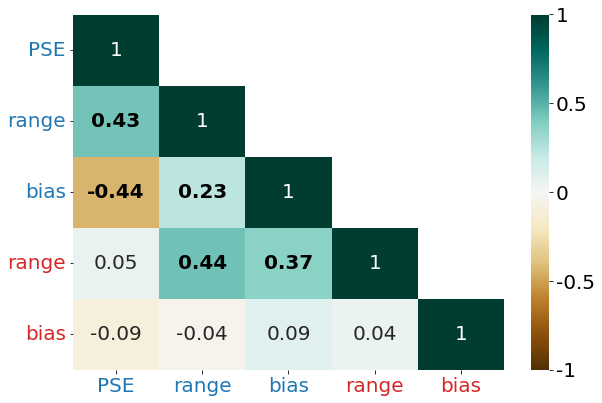

In [16]:
# fig,ax = plt.subplots(nrows=1,ncols = 1, figsize=(6,4.5))
fig,ax = plt.subplots(nrows=1,ncols = 1, figsize=(9,6))
# ax = axs[0]

# Create a custom annotation array
annot = np.array([[f"{val:.2f}" if val <.999 else "1" for val in row] for row in r_all])
sns.heatmap(r_all,vmin=-1,vmax=1,annot=annot,cbar=True,cmap=cmap,ax=ax,fmt='', annot_kws={"fontsize": 20})
ax.set_xticklabels(['PSE_det','range_det','bias_det','range_disc','bias_disc'], rotation=0)
ax.set_yticklabels(['PSE_det','range_det','bias_det','range_disc','bias_disc'], rotation=0)

# Specify cells to be bolded (example: first row and first column)
rows, cols = np.where(corrected_p_values==1)
true_indices = list(zip(rows, cols))
# Update the font properties for the specified cells

# try:
rows, cols = r_all.shape
text_count = len(ax.texts)
for index in range(text_count):
    # Access the text object
    text_obj = ax.texts[index]
    print(text_obj)
    
    # Get its properties
    x, y = text_obj.get_position()
    text = text_obj.get_text()
    
    for ind, (i,j) in enumerate(true_indices):
        if (x==j+.5) & (y==i+.5):
            text_obj.set_weight('bold')
            text_obj.set_color('k')
            break

for i, label in enumerate(ax.get_xticklabels()):
    if 'det' in label.get_text():
        label.set_color('tab:blue')
    elif 'disc' in label.get_text():
        label.set_color('tab:red')

for i, label in enumerate(ax.get_yticklabels()):
    if 'det' in label.get_text():
        label.set_color('tab:blue')
    elif 'disc' in label.get_text():
        label.set_color('tab:red')

# Modify and reapply x-axis tick labels
x_labels = [label.get_text().split('_')[0] for label in ax.get_xticklabels()]
ax.set_xticklabels(x_labels, rotation=0, ha='center')  # Apply the new labels

# Modify and reapply x-axis tick labels
y_labels = [label.get_text().split('_')[0] for label in ax.get_yticklabels()]
ax.set_yticklabels(y_labels, rotation=0, ha='right')  # Apply the new labels

# Access the colorbar
cbar = ax.collections[0].colorbar

# Set the number of ticks
ticks = [-1,-.5,0,0.5,1]
cbar.set_ticks(ticks)  # Set the ticks
cbar.set_ticklabels([f"{v:.1f}" if v in [-.5,.5] else f"{v:.0f}" for v in ticks])  # Optional: format tick labels


plt.tight_layout()
plt.savefig(f'{results_loc}/curvefit_subtlety_vs_playfight_onlynecparams_FDRcorr.png', dpi=300, bbox_inches='tight')